In [1]:
import pandas as pd
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error


Data Cleaning

In [2]:
df = pd.read_csv(r'Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df = df.drop(['area_type','balcony','society','availability'],axis=1)
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [4]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [5]:
#handle missing values in location column
df['location'].value_counts() #count of houses in whitefield and Sarjapur Road are more,we can fill the missing values with these two locations
#df['location'].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [6]:
df['location']= df['location'].fillna("Sarjapur Road")
df['location'].value_counts()
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [7]:
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [8]:
df['size'].value_counts()


size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [9]:
df['size']=df['size'].fillna('2 BHK')
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [10]:
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [11]:
df['bath']=df['bath'].fillna(round(df['bath'].median()))

In [12]:
df['bath'].value_counts()

bath
2.0     6981
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
11.0       3
13.0       3
16.0       2
14.0       1
27.0       1
40.0       1
15.0       1
18.0       1
Name: count, dtype: int64

In [13]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df['bath']=df['bath'].astype(int)


In [16]:
#.apply is used to map the single function to each and every element
df['location']=df["location"].apply(lambda x:x.strip())

loc=df["location"].value_counts()

loc_less_than_10=loc[loc<=10]

df["location"]=df["location"].apply(lambda x:'others' if x in loc_less_than_10 else x)#removing the locations which are less than 10
df["location"].value_counts()


location
others                  2928
Whitefield               508
Sarjapur  Road           364
Electronic City          275
Thanisandra              226
                        ... 
NGR Layout                11
Doddakallasandra          11
Banashankari Stage V      11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [17]:
#handling size column
df['size'].value_counts()

out=[int(i.split()[0]) for i in df['size']]#split will give output as list in 0th index we have number

df["bhk"]=out#adding new column bhk with just the number where it is present in size 
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [18]:
#handling total_sqft column
#since it has some object type like ranges,so we need convert that into numeric
#this func is about spliting those range type values
def clean_sqft(sqft):
    li=str(sqft).split('-')
    try:
        if len(li)==2:
            return (float(li[2])+float(li[1]))/2
        else:
            return float(li[0])
    except:#if i gets value like 1234-
        return None
    
df['total_sqft']=df['total_sqft'].apply(clean_sqft)
df['total_sqft']=df["total_sqft"].fillna(round(df["total_sqft"].mean()))#filling null values with rounding of there value so there is no decimal point

Feature engineering

In [19]:
#create price_per_sqft
#formula:price/total_sqft
df["price_per_sqft"]=(df["price"]*100000)/df["total_sqft"] #*100000 because prices are in lakhs
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


Handling Outliers

In [20]:
#in total_sqft there are values like 1.000000 of sqft which is not normal,i.e,
#total_sqft/bhk=>300,which wil be realestic
#in total_sqft column if we have less than 300 sqft per bhk then we can say that it is outlier
df=df[df["total_sqft"]/df["bhk"]>=300]

In [21]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,1609.104683,2.579667,114.455648,2.666809,6433.552419
std,1286.606256,1.099383,156.421987,0.995743,4356.473098
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1125.000000,2.000000,50.000000,2.000000,4232.164450
50%,1323.000000,2.000000,71.000000,3.000000,5350.289762
75%,1705.000000,3.000000,120.000000,3.000000,7028.571429
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [22]:
#handling outliers in bhk removing all the outliners which are greater than 6
df=df[df["bhk"]<=6]

In [23]:
#handling outliers for bath
#bhk+2-because we can have atleast 2 more bathroom than number of beedrooms
#it removes unrealastic rows where the number of bathrooms
#(bath) is suspiciously high compared to number of bedroom
df=df[df['bath']<(df['bhk']+2)]

In [24]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11467.000000,11467.000000,11467.000000,11467.000000,11467.000000
mean,1562.687620,2.496207,108.530990,2.607831,6348.032926
std,1174.517469,0.911130,137.233476,0.855586,4215.967386
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1120.000000,2.000000,49.750000,2.000000,4224.028253
50%,1310.000000,2.000000,70.000000,3.000000,5327.868852
75%,1680.000000,3.000000,115.000000,3.000000,6969.394274
max,52272.000000,7.000000,2912.000000,6.000000,176470.588235


<Axes: xlabel='price_per_sqft'>

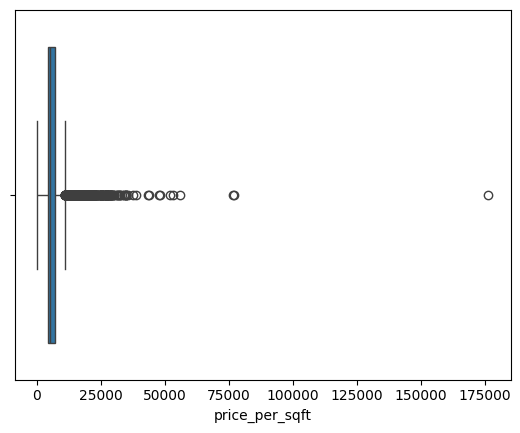

In [25]:
sns.boxplot(x="price_per_sqft",data=df)

IQR Method of handling outliers

<Axes: xlabel='price_per_sqft'>

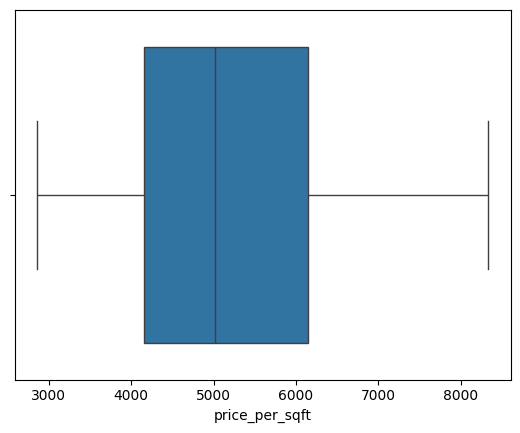

In [26]:
q1=df["price_per_sqft"].quantile(0.25)
q3=df["price_per_sqft"].quantile(0.75)

IQR=q3-q1

lower=q1-0.5*IQR #0.5 is a standard value used,any value can be used
upper=q3+0.5*IQR

df=df[(df["price_per_sqft"]>=lower)&(df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)


In [27]:
#after all the cleaning,our index value has been jumbled up
df.reset_index(inplace=True)
df

,index,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...
9406,13310,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
9407,13312,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
9408,13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
9409,13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


In [28]:
#now,after all the cleaning,we can remove the price_per_sqft which 
df=df.drop(["index","size"],axis=1)
df

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3,95.00,3,6245.890861
4,Kothanur,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...
9406,Rachenahalli,1050.0,2,52.71,2,5020.000000
9407,Bellandur,1262.0,2,47.00,2,3724.247227
9408,Green Glen Layout,1715.0,3,112.00,3,6530.612245
9409,Whitefield,3453.0,4,231.00,5,6689.834926


Encoding

In [29]:
#encoding location
df=pd.get_dummies(df,columns=["location"],drop_first=True,dtype=int)

In [30]:
df.columns

Index(['total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft',
       'location_1st Phase JP Nagar', 'location_2nd Stage Nagarbhavi',
       'location_5th Block Hbr Layout', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar',
       ...
       'location_Vishveshwarya Layout', 'location_Vishwapriya Layout',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_others'],
      dtype='str', length=235)

In [31]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)#identifiees unique values and map it,fit will learn the data and transform will map

ML model training(Random forest)

1.Spliting data for training and testing

In [32]:
#Divide into input and output
X=df.drop(["price","price_per_sqft"],axis=1)#location because object column xis input
y=df.price#y is output

In [33]:
#split the data into training and test data
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

In [34]:
#model training using GridSearchCv
model=RandomForestRegressor(random_state=42)
params={
    "n_estimators":[100,150,200],
    "max_depth":[3,4,5,6,7]
}
grid=GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(Xtrain,ytrain)
print("Best params: ",grid.best_params_)
print("Best Score: ",grid.best_score_)

Best params:  {'max_depth': 7, 'n_estimators': 150}
Best Score:  0.8015252697787065


In [35]:
#model training with best estimators
best_model=grid.best_estimator_

In [36]:
ypred=grid.predict(Xtest)
ypred

array([ 87.38679762,  80.00988068,  60.8893233 , ...,  50.03869473,
       119.02433769,  31.90575464], shape=(2824,))

In [37]:
print("Testing Eff:",grid.score(Xtrain,ytrain))
print("Training Eff: ",grid.score(Xtest,ytest))

Testing Eff: 0.8781470398556804
Training Eff:  0.8345848257425087


In [38]:
#model accurecy
print("R2: ",r2_score(ytest,ypred))
#model error
print("MAE: ",mean_absolute_error(ytest,ypred))

R2:  0.8345848257425087
MAE:  14.50236872832318


In [39]:
#saving the cleaned dataset
df.to_csv("Cleaned_df.csv")

In [40]:
#saving the model
joblib.dump(best_model,'rf_model.joblib')

['rf_model.joblib']

In [41]:
#storing the column [location] in the form of list 
joblib.dump(Xtrain.columns.tolist(),"model_columns.joblib")

['model_columns.joblib']